# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [1]:
# importar librerías
import pandas as pd
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [3]:
# mostrar las primeras 5 filas
df.head(5)

                                user_id        date landing     region  \
0  26f3052e-8500-44ea-8fff-06de65258abb  2026-01-01       A      Norte   
1  92378c09-4bbf-40c7-945e-82b84f392d22  2026-01-23       A  Occidente   
2  a4397360-40e5-45d6-a7ff-dcb4da2c9a1f  2026-01-01       B     Centro   
3  7ca3a26f-1e6c-44aa-9b09-b8cb01112956  2026-01-22       A     Centro   
4  8dc9593b-5b9c-479d-848b-a99493920419  2026-01-16       A        Sur   

  dispositivo traffic_source   user_type  converted  gasto  
0      Mobile          Email  Recurrente          1  38.08  
1      Mobile        Organic       Nuevo          0   0.00  
2      Mobile        Organic       Nuevo          0   0.00  
3      Mobile            Ads       Nuevo          0   0.00  
4      Mobile        Organic       Nuevo          0   0.00  

In [4]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


La columna "date" es de tipo de dato **object** cuando debe de ser **datetime64** 
Ninguna de las 9 columna del dataset tiene datos nulos, todas las columnas se observan con 40000

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [5]:
df["user_id"].nunique()

40000

 **Variable `date`**  
Explorar rango de fechas

In [6]:
# Resumen estadístico
df["date"].describe()

count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [7]:
df['date'] = pd.to_datetime(df['date'])

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   user_id         40000 non-null  object        
 1   date            40000 non-null  datetime64[ns]
 2   landing         40000 non-null  object        
 3   region          40000 non-null  object        
 4   dispositivo     40000 non-null  object        
 5   traffic_source  40000 non-null  object        
 6   user_type       40000 non-null  object        
 7   converted       40000 non-null  int64         
 8   gasto           40000 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 2.7+ MB


In [9]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01 00:00:00
Fecha máxima: 2026-01-28 00:00:00


**Variable `gasto` (numérica)**

In [10]:
# Resumen estadístico
df["gasto"].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [11]:
# Resumen estadístico de usuarios que se convirtieron
df[df["converted"] == 1]["gasto"]

0         38.08
9         27.61
17        42.97
25        70.59
27       119.26
          ...  
39967    141.21
39971     37.76
39973     49.17
39974     72.76
39999    120.37
Name: gasto, Length: 5706, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [12]:
# Explorar variables categóricas y cómo se distribuyen

print("\nConteo de categorías:")

columnas_cat = ['landing', 'region', 'dispositivo', 'traffic_source', 'user_type']
df[columnas_cat].describe()



Conteo de categorías:


       landing region dispositivo traffic_source user_type
count    40000  40000       40000          40000     40000
unique       2      5           2              4         2
top          B  Norte      Mobile        Organic     Nuevo
freq     20018  11166       24829          17987     26033

In [13]:
df['traffic_source'].value_counts()

Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64

In [14]:
df['traffic_source'].value_counts(normalize=True)

Organic     0.449675
Ads         0.298375
Email       0.153075
Referral    0.098875
Name: traffic_source, dtype: float64

In [15]:
df['traffic_source'].describe()

count       40000
unique          4
top       Organic
freq        17987
Name: traffic_source, dtype: object

In [16]:
df['region'].describe()

count     40000
unique        5
top       Norte
freq      11166
Name: region, dtype: object

In [17]:
df['dispositivo'].describe()

count      40000
unique         2
top       Mobile
freq       24829
Name: dispositivo, dtype: object

In [18]:
df['user_type'].describe()

count     40000
unique        2
top       Nuevo
freq      26033
Name: user_type, dtype: object


Las variables categoricas son: 
- `landing`
- `region`
- `dispositivo`
- `traffic_source`
- `user_type`

Todas tiene **40000** valores
 
La mayoria de usuarios llegan de forma natural (~ 45%) y casi ningun usuario llega referido (~ 9%)


## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [19]:


# Gasto por versión
gasto_A = df[(df['landing'] == 'A')& (df['converted'] == 1)]['gasto']
gasto_B = df[(df['landing'] == 'B')& (df['converted'] == 1)]['gasto']

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)




(2512, 3194)

In [20]:
from scipy.stats import levene

levene(gasto_A, gasto_B)

LeveneResult(statistic=29.17646453202917, pvalue=6.875301988016449e-08)

In [21]:
# Aplicar prueba
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(gasto_A, gasto_B, equal_var=False)
print(f"Estadístico t: {t_stat}")
print(f"Valor P: {p_value}")


Estadístico t: -9.48101092267275
Valor P: 3.627602231521493e-21


### 📝 Conclusión e interpretación

**Decisión:**
	
 H₀ (Hipótesis Nula): Las varianzas de los dos grupos son iguales (varianzas homogéneas).
 
 H₁ (Hipótesis Alternativa): Las varianzas de los dos grupos son diferentes (varianzas heterogéneas).
 
Rechazas la Hipótesis Nula (H₀) de forma contundente, es menor al umbral estándar de 0.05.

**Interpretación de negocio:**  
El gasto promedio del primer grupo (gasto_A) es SIGNIFICATIVAMENTE MENOR que el del segundo grupo (gasto_B).

Gasto Promedio A < Gasto Promedio B

---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen diferencias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** ...
- **Hipótesis alternativa (H₁):** ...

In [22]:
import statsmodels.api as sm
# Número de usuarios convertidos por página
usuarios_A = df[(df['landing'] == 'A') & (df['converted'] == 1)]['user_id']
usuarios_B = df[(df['landing'] == 'B') & (df['converted'] == 1)]['user_id']
# Total de usuarios por página
total_A = df[df['landing'] == 'A']['user_id'].count()
total_B = df[df['landing'] == 'B']['user_id'].count()

print("Usuarios convertidos por página:\n", usuarios_A, usuarios_B)
print("\nTotal de usuarios por página:\n", total_A, total_B)


Usuarios convertidos por página:
 0        26f3052e-8500-44ea-8fff-06de65258abb
17       23293fec-8583-4adb-838d-601d0f3a2ec8
27       523c2cb2-c5dd-442e-9c0e-85298572e132
44       023d5823-677c-4f1a-80dd-ac9d9f595897
45       7c1083e7-1153-4064-9f66-690981138fe2
                         ...                 
39922    d226309f-74ad-4801-b35c-fe3b9ccae945
39955    240eb558-c29f-4dec-9a4c-af2439064356
39958    318f747f-adad-401a-a13c-3d0f266825bc
39965    a2604997-5655-49c7-9fe7-061efb16771c
39974    8b586ad5-a4de-4296-a25d-6fc19809bfe8
Name: user_id, Length: 2512, dtype: object 9        be5e7d86-884e-467f-9cf2-ece406b9eebf
25       cd7e07df-50ce-42e5-b5f3-47dde51f071e
30       e2d82e66-2c91-4755-ba0a-579cb8d4ec69
62       185f5f3d-85ac-4d2b-b733-221bbb485ce1
65       8e22b5d8-0a32-4545-b474-3d97e62535b8
                         ...                 
39966    454cce96-7529-4e4b-9054-aae51f6b12a5
39967    d55d337f-fb56-4248-8c24-1223135ebff6
39971    31117b22-37cf-4b24-ab2f-eaf14fcf095b
399

In [23]:
# Aplicar prueba
from scipy.stats import ttest_ind

exitos = [len(usuarios_A), len(usuarios_B)]
totales = [total_A, total_B]
cr_A = len(usuarios_A) / total_A
cr_B = len(usuarios_B) / total_B

z_stat, p_value = sm.stats.proportions_ztest(count=exitos, nobs=totales)

# Visualizar resultados
print(f"Tasa de conversión A: {cr_A:.2%} ({len(usuarios_A)} / {total_A})")
print(f"Tasa de conversión B: {cr_B:.2%} ({len(usuarios_B)} / {total_B})")
print("-" * 40)
print(f"Estadístico Z: {z_stat:.4f}")
print(f"Valor P: {p_value}")

Tasa de conversión A: 12.57% (2512 / 19982)
Tasa de conversión B: 15.96% (3194 / 20018)
----------------------------------------
Estadístico Z: -9.6774
Valor P: 3.7629765627523803e-22


### 📝 Conclusión e interpretación

**Decisión:**  
Decisión: Rechazas la Hipótesis Nula: No existe una diferencia estadísticamente significativa entre las tasas de conversión del Grupo A y del Grupo B. Cualquier diferencia observada se debe únicamente al azar.

Aceptas la Hipótesis Alternativa: Existe una diferencia estadísticamente significativa entre la tasa de conversión del Grupo A y la del Grupo B.

Resultado: La diferencia entre ambas tasas de conversión no es fruto del azar. Es una diferencia real y estadísticamente significativa.

**Interpretación de negocio:**  
Los resultados demuestran de forma contundente que la Página B es más efectiva para generar conversiones que la Página A

Mayor rendimiento: La Página B alcanzó una tasa de conversión del 15.96% (3,194 usuarios) frente al 12.57% (2,512 usuarios) de la Página A.


## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** ...
- **Hipótesis alternativa (H₁):** ...

In [24]:

tabla = pd.crosstab(df['traffic_source'], df['converted'])
print(tabla)


converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549


In [25]:
# Aplicar prueba
chi2_stat, p_value, dof, expected = chi2_contingency(tabla)

print(f"Estadístico chi-cuadrado: {chi2_stat}")
print(f"Valor P: {p_value}")
print(f"Grados de libertad: {dof}")
print("\nFrecuencias esperadas:")
print(expected)

Estadístico chi-cuadrado: 8.662108841397938
Valor P: 0.0341375947833914
Grados de libertad: 3

Frecuencias esperadas:
[[10232.47225  1702.52775]
 [ 5249.55405   873.44595]
 [15421.15445  2565.84555]
 [ 3390.81925   564.18075]]


### 📝 Conclusión e interpretación

**Decisión:**  

Se rechaza la hipótesis nula. Dado que el valor P obtenido (0.0341) es menor que el nivel de significancia estándar de 0.05 (α=0.05), existe evidencia estadística suficiente para rechazar la hipotesis nula.

**Interpretación de negocio:**  
 La prueba demuestra que existe una relación estadísticamente significativa entre la fuente de tráfico y la tasa de conversión. Es decir, la probabilidad de que un usuario convierta depende del canal por el que llegó (Ads, Email, Organic o Referral).


## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** ...
- **Hipótesis alternativa (H₁):** ...

In [26]:
tabla = pd.crosstab(df['user_type'], df['converted'])
print(tabla)

converted       0     1
user_type              
Nuevo       22295  3738
Recurrente  11999  1968


In [27]:
# Aplicar prueba
chi2_stat, p_value, dof, expected = chi2_contingency(tabla)

print(f"Estadístico chi-cuadrado: {chi2_stat}")
print(f"Valor P: {p_value}")
print(f"Grados de libertad: {dof}")
print("\nFrecuencias esperadas:")
print(expected)


Estadístico chi-cuadrado: 0.5134849494478645
Valor P: 0.4736341272301974
Grados de libertad: 1

Frecuencias esperadas:
[[22319.39255  3713.60745]
 [11974.60745  1992.39255]]


### 📝 Conclusión e interpretación

**Decisión:**  

No se rechaza la hipótesis nula.

El valor P obtenido (0.4736) es significativamente mayor que el nivel de significancia del 5% (α=0.05). Esto indica que no existe evidencia estadística suficiente para afirmar que exista una relación entre el tipo de usuario y su probabilidad de convertir.

**Interpretación de negocio:** 

Los datos demuestran que el tipo de usuario (Nuevo vs. Recurrente) no influye en la tasa de conversión:
- Tasas de conversión prácticamente idénticas:
    - Usuarios Nuevos: 14.36% de conversión (3,738 convertidos de 26,033 totales).
    - Usuarios Recurrentes: 14.09% de conversión (1,968 convertidos de 13,967 totales).

## 📊 Paso 6:Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

In [28]:

tabla = pd.crosstab(df['traffic_source'], df['converted'])
tabla 


converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549

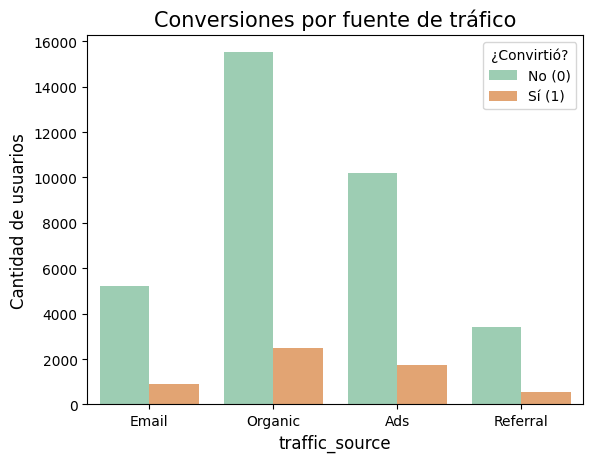

In [29]:

sns.countplot(data=df, x='traffic_source', hue='converted', palette = ["#95D5B2", "#F4A261"])
sns

# Añadir detalles
plt.title('Conversiones por fuente de tráfico', fontsize=15)
plt.xlabel('traffic_source', fontsize=12)
plt.ylabel('Cantidad de usuarios', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()



Este gráfico compara la cantidad total de usuarios atraídos por cada canal de tráfico (Email, Organic, Ads y Referral) dividiéndolos entre quienes no convirtieron (No - 0, en verde) y quienes sí convirtieron (Sí - 1, en naranja).

Conversiones por fuente de trafico, vemos la cantidad de usuarios por fuente de trafico.
La mayor cantidad de usuarios convertidos son de manera Organica pero tambien es la fuente que más usuarios no convertidos tiene. 
La mayor tasa de conversión (ese es Email, con 14.99%)


### Relación entre el tipo de usuario y la conversión

In [30]:
tabla = pd.crosstab(df['user_type'], df['converted'])
tabla 


converted       0     1
user_type              
Nuevo       22295  3738
Recurrente  11999  1968

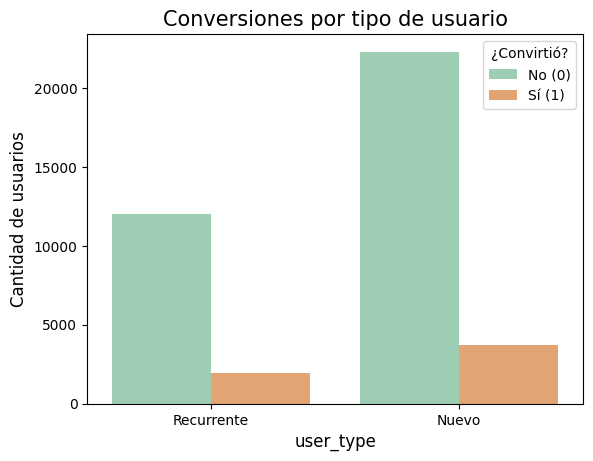

In [31]:
sns.countplot(data=df, x='user_type', hue='converted', palette = ["#95D5B2", "#F4A261"])

# Añadir detalles
plt.title('Conversiones por tipo de usuario', fontsize=15)
plt.xlabel('user_type', fontsize=12)
plt.ylabel('Cantidad de usuarios', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()


Cantidad de usuarios: Muestra el volumen total de usuarios (desde 0 hasta más de 20,000).
Tipos de usuario: Compara dos categorías/grupos de usuarios

Verde claro — No (0): Usuarios que no realizaron la conversión.
Naranja — Sí (1): Usuarios que sí convirtieron.

El segundo grupo (derecha) es significativamente mayor: Tiene alrededor de 26,000 usuarios en total, en comparación con el primer grupo (izquierda), que suma aproximadamente 14,000 usuarios.

Grupo de la izquierda: Tasa de conversión estimada: ≈14.3%

Grupo de la derecha: Tasa de conversión estimada: ≈14.7%

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders


Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?

---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
Versión B (Variante): Registró un gasto promedio por usuario convertido superior al de la Versión A.
Versión A (Control): Presentó un gasto promedio menor por cada usuario que completó una transacción.

- **Interpretación:**
La Versión B demuestra ser la propuesta más efectiva para la rentabilidad del negocio. Al actualizar el sitio a la Versión B, la empresa no solo captura más compradores, sino que también aumenta el valor medio de cada transacción realizada.

<br>

**Tasa de conversión:** 
 Versión A: 12.57%
 Versión B: 15.96%
 Diferencia de +3.39%

 **Rendimiento Relativo**
 Versión A: Línea base
 Versión B: +27.0% superior

- **Interpretación:**
Eficiencia Superior: La Versión B logró convertir a 16 de cada 100 visitantes, mientras que la Versión A solo convirtió a 12.5 de cada 100.

Mejora Relativa del 27%: La Versión B no solo supera a la A, sino que representa un incremento del +27% en la efectividad general de la página para transformar visitas en ventas/conversiones.

Significancia Estadística: La diferencia entre ambas tasas fue validada estadísticamente (vía prueba Z / Chi-cuadrada), confirmando que el resultado no es producto del azar, sino de la superioridad en el diseño/experiencia de la página B.

Conclusión: Para la métrica de Tasa de Conversión, la Versión B es la clara ganadora.

---

#### 📊 **Segmentación por fuente de tráfico**
- Observacion aquí
- **Interpretación:**
1. Intención de Compra Calificada (Ads & Email)
    - Son los canales más rentables por visita, ideales para campañas directas de conversión y captación pagada.
2. Tráfico de Exploración (Orgánico & Referidos)
    - Generan volumen e interacciones, pero requieren más puntos de contacto (nurturing) antes de estar listos para convertir.
3. Resultado de la Prueba Estadística (Chi-Cuadrada)
    - Se confirmó que existe una relación estadísticamente significativa entre la Fuente de Tráfico y la Probabilidad de Conversión.
4. 
 ---

#### 📊 **Segmentación por tipo de usuario**
- Observacion aquí
- **Interpretación:**
1. Impacto Universal de la Rediseñada (Versión B)
    - ambos grupos se beneficiaron por igual de la Versión B. No hubo resistencia al cambio por parte de los recurrentes y la rediseñada funcionó excelente introduciendo la marca a los nuevos.
3. Ausencia de Diferencia Estadística Significativa
    - La prueba de independencia mostró que el tipo de usuario no influye de forma determinante en la probabilidad de convertir.
---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:** 
- Escalar presupuesto en Ads y Email: Reasignar más inversión hacia campañas pagadas e intensificar las secuencias automatizadas por correo, ya que traen al público con mejor tasa de retorno.
-  Adaptar la estrategia para Orgánico/Referidos: En lugar de enviarlos a una página de venta directa, dirigirlos a contenido informativo o captar su correo a cambio de un incentivo, convirtiéndolos en leads para venderles posteriormente por Email.
-  Oportunidad para aumentar el Lifetime Value (LTV): 